In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mplcm
import matplotlib.colors as colors

from parameters import *
import save_n_load as sl
import clustering as cl
import hit_stat as hs
import aux

bg_data_dir = BG_DATA_DIR

bg_types_vd = BG_TYPES #["Ar39GenInLAr"]
bg_data_dir_0 = "/eos/project-e/ep-nu/pbarhama/sn_saves/new_compgraph_prod_background_pds/"
#bg_data_dir = "/eos/project-e/ep-nu/pbarhama/sn_saves/new_photon_lib_prod_background_pds/"
#bg_data_dir_0 = "/eos/project-e/ep-nu/pbarhama/sn_saves/hd_prod_background_pds/"

adc_mode = "normal"
sim_mode = "xe"
bg_types = BG_TYPES#, "Rn222ChainRn222GenInLAr", "NeutronGenInRock"]

In [4]:
bg_limit = 30
bg_sample_length = 8.5#4.492 #8.5 # in ms
bg_lenght = bg_limit * bg_sample_length * 20

#bg_total_hits, bg_hit_list_per_event, _, bg_total_hits_per_type, bg_hit_list_per_event_per_type =\
#                                    sl.load_all_backgrounds_chunky_type_separated(limit=bg_limit, detector="VD", bg_data_dir=bg_data_dir_0, adc_mode=adc_mode,
#                                            sim_mode=sim_mode, offset=2, bg_types=bg_types);

bg_total_hits_ar, bg_hit_list_per_event_ar, _, bg_total_hits_per_type_ar, bg_hit_list_per_event_per_type_ar =\
        sl.load_all_backgrounds_chunky_type_separated(limit=bg_limit, detector="VD", bg_data_dir=BG_DATA_DIR, adc_mode=adc_mode,
                                        sim_mode="xe", offset=2, bg_types=bg_types_vd,
                                                     verbose=0);

bg_total_hits, bg_hit_list_per_event, _, bg_total_hits_per_type, bg_hit_list_per_event_per_type =\
        sl.load_all_backgrounds_chunky_type_separated(limit=bg_limit, detector="VD", bg_data_dir=BG_DATA_DIR, adc_mode=adc_mode,
                                        sim_mode="xe", offset=2, bg_types=bg_types_vd,
                                                     verbose=0);

In [7]:
%matplotlib widget

plot="xe"

fig = plt.figure(1)
ax = fig.add_subplot(111)

fig2 = plt.figure(2)
ax2 = fig2.add_subplot(111)

NUM_COLORS = 13
cm = plt.get_cmap('tab20b')
cNorm  = colors.Normalize(vmin=0, vmax=NUM_COLORS-1)
scalarMap = mplcm.ScalarMappable(norm=cNorm, cmap=cm)
ax.set_prop_cycle(color=[scalarMap.to_rgba(i) for i in range(NUM_COLORS)])

NUM_ARAPUCAS = 184
#NUM_ARAPUCAS = 480 # For HD

ax.set_xlabel("Number of hits per ms / arapuca")
ax.set_xscale('log')
ax2.set_xlabel("Number of hits per ms / arapuca ")
ax2.set_xscale('log')
#ax.set_xlim(left=0.5, right=1000)

for i, type in enumerate(bg_types):
    print(i, type)
    
    total_len = 0
    lens = []
    total_len_ar = 0
    lens_ar = []
    
    for hit_list in bg_hit_list_per_event_per_type[i]:
        total_len += len(hit_list)
        lens.append(len(hit_list))
    for hit_list in bg_hit_list_per_event_per_type_ar[i]:
        total_len_ar += len(hit_list)
        lens_ar.append(len(hit_list))
    
    average_len = total_len / len(bg_hit_list_per_event_per_type[i])
    rate = average_len / bg_sample_length * 1/NUM_ARAPUCAS
    
    average_len_ar = total_len_ar / len(bg_hit_list_per_event_per_type_ar[i])
    rate_ar = average_len_ar / bg_sample_length * 1/NUM_ARAPUCAS
    
    if rate < 1:
        ax.hist(np.array(lens) / bg_sample_length /NUM_ARAPUCAS, bins=np.linspace(0.01, 1, 70), label=type, density=True)
    if rate >= 0.01 and (plot=="BOTH" or plot=="xe"):
        ax2.hist(np.array(lens) / bg_sample_length / NUM_ARAPUCAS, bins=np.linspace(0.01, 2, 300), label=type, density=True)
    #ax.hist(np.array(lens) / bg_sample_length, bins=np.logspace(-1, 2, 40), label=type, density=True)
    if rate_ar >= 0.1 and (plot=="BOTH" or plot=="aronly"):
        ax2.hist(np.array(lens_ar) / bg_sample_length, bins=np.linspace(3, 300, 300), label=type + " (Ar)")#, density=True, histtype='step')#, linestyle='dashed')
    
    print(rate, "(hits per ms / arapuca)")
    print("Min:", np.min(lens)/bg_sample_length, "Max:", np.max(lens)/bg_sample_length)
    print(rate_ar, "(hits per ms / arapuca) ArOnly")

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

box = ax2.get_position()
ax2.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

0 Ar39GenInLAr
2.8880370843989773 (hits per ms / arapuca)
Min: 496.94117647058823 Max: 563.6470588235294
2.8880370843989773 (hits per ms / arapuca) ArOnly
1 Kr85GenInLAr
0.3314855072463768 (hits per ms / arapuca)
Min: 0.0 Max: 73.17647058823529
0.3314855072463768 (hits per ms / arapuca) ArOnly
2 Ar42GenInLAr
0.0003239556692242115 (hits per ms / arapuca)
Min: 0.0 Max: 0.7058823529411765
0.0003239556692242115 (hits per ms / arapuca) ArOnly
3 K42From42ArGenInLAr
0.0005040494458653026 (hits per ms / arapuca)
Min: 0.0 Max: 2.0
0.0005040494458653026 (hits per ms / arapuca) ArOnly
4 Rn222ChainRn222GenInLAr
0.14651427962489344 (hits per ms / arapuca)
Min: 9.294117647058824 Max: 50.8235294117647
0.14651427962489344 (hits per ms / arapuca) ArOnly
5 Rn222ChainPo218GenInLAr
0.15735720375106563 (hits per ms / arapuca)
Min: 7.411764705882353 Max: 57.76470588235294
0.15735720375106563 (hits per ms / arapuca) ArOnly
6 Rn222ChainPb214GenInLAr
0.006070971867007672 (hits per ms / arapuca)
Min: 0.0 Max: 3

In [8]:
# What about the average PEs for each of these BG types?
for i, type in enumerate(bg_types):
    print(i, type)
    
    avg_pes_list = []
    total_pes = []
    pes = []
    lens = 0
    
    for hit_list in bg_hit_list_per_event_per_type[i]:
        if len(hit_list) == 0:
            continue
        total_pes.extend(hit_list[:, -1])
        avg_pes_list.append(np.mean(hit_list[:, -1]))
        lens += len(hit_list)
    
    average_pes = np.sum(total_pes) / lens
    rate = average_pes / bg_sample_length
    
    #print(rate, "(PEs per ms)")
    print(average_pes, "average PEs per hit")
    print("Min:", np.min(total_pes), "Max:", np.max(total_pes))
    print("--------")

0 Ar39GenInLAr
10.996388968963121 average PEs per hit
Min: 2.430000066757202 Max: 22904.18359375
--------
1 Kr85GenInLAr
11.783855367381943 average PEs per hit
Min: 2.4607691764831543 Max: 22807.060546875
--------
2 Ar42GenInLAr
13.085221038837181 average PEs per hit
Min: 3.0505127906799316 Max: 723.4530639648438
--------
3 K42From42ArGenInLAr
10.173074785297063 average PEs per hit
Min: 2.6761538982391357 Max: 210.77615356445312
--------
4 Rn222ChainRn222GenInLAr
15.773573493316599 average PEs per hit
Min: 2.66076922416687 Max: 10230.8759765625
--------
5 Rn222ChainPo218GenInLAr
16.362258965872662 average PEs per hit
Min: 2.706923007965088 Max: 17686.283203125
--------
6 Rn222ChainPb214GenInLAr
15.59210826791084 average PEs per hit
Min: 2.6453845500946045 Max: 9164.7783203125
--------
7 Rn222ChainBi214GenInLAr
14.99867299545055 average PEs per hit
Min: 2.7300000190734863 Max: 20747.052734375
--------
8 Rn222ChainPb210GenInLAr
7.146999992132187 average PEs per hit
Min: 3.327435970306396

/tmp/ipykernel_3000/3570567903.py:17: RuntimeWarning: invalid value encountered in double_scalars
  average_pes = np.sum(total_pes) / lens


ValueError: zero-size array to reduction operation minimum which has no identity

In [9]:
%matplotlib widget
fig3 = plt.figure(3)
ax3 = fig3.add_subplot(111)

#ax3.set_prop_cycle(color=[scalarMap.to_rgba(i) for i in range(NUM_COLORS)])

ax3.set_xlabel("Number of clusters per ms")
ax3.set_xscale('linear')
#ax.set_xlim(left=0.5, right=1000)

for i, type in enumerate(bg_types):
    print(i, type)
    
    total_len = 0
    lens = []
    cluster_nums = []
    for hit_list in bg_hit_list_per_event_per_type[i]:
        total_len += len(hit_list)
        lens.append(len(hit_list))
        
        candidate_clusters_2, candidate_hit_multiplicities = cl.time_clustering(hit_list, 0.2, 0.1,
                                                                                5, verbose=0)
        cluster_nums.append(len(candidate_clusters_2))
    
    average_cluster_num = np.mean(cluster_nums)
    rate = average_cluster_num / bg_sample_length
    
    print("Min:", np.min(cluster_nums) / bg_sample_length, "Max:", np.max(cluster_nums) / bg_sample_length)
    print(rate, "clusters per ms")
    
    if rate > 0.001:
        ax3.hist(np.array(cluster_nums) / bg_sample_length, bins=np.linspace(0.0001, 15, 70), label=type, density=True)
        #ax3.hist(np.array(cluster_nums) / bg_sample_length, bins=20, label=type, density=True)


box = ax.get_position()
ax3.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5))

Canvas(toolbar=None)

0 Ar39GenInLAr
Min: 0.0 Max: 0.47058823529411764
0.05450980392156862 clusters per ms
1 Kr85GenInLAr
Min: 0.0 Max: 0.11764705882352941
0.0005882352941176471 clusters per ms
2 Ar42GenInLAr
Min: 0.0 Max: 0.0
0.0 clusters per ms
3 K42From42ArGenInLAr
Min: 0.0 Max: 0.0
0.0 clusters per ms
4 Rn222ChainRn222GenInLAr
Min: 0.0 Max: 1.5294117647058822
0.5252941176470588 clusters per ms
5 Rn222ChainPo218GenInLAr
Min: 0.0 Max: 1.8823529411764706
0.6615686274509803 clusters per ms
6 Rn222ChainPb214GenInLAr
Min: 0.0 Max: 0.0
0.0 clusters per ms
7 Rn222ChainBi214GenInLAr
Min: 0.0 Max: 2.0
0.5756862745098039 clusters per ms
8 Rn222ChainPb210GenInLAr
Min: 0.0 Max: 0.0
0.0 clusters per ms
9 Rn220ChainPb212GenInLAr
Min: 0.0 Max: 1.411764705882353
0.1784313725490196 clusters per ms
10 K40GenInCPA
Min: 0.0 Max: 0.0
0.0 clusters per ms
11 U238ChainGenInCPA
Min: 0.0 Max: 0.0
0.0 clusters per ms
12 K42From42ArGenInCPA
Min: 0.0 Max: 0.0
0.0 clusters per ms
13 Rn222ChainPo218GenInCPA
Min: 0.0 Max: 0.0
0.0 clust

In [ ]:
((375 + 325) * 732 * 2) / (325 * 2 * 675 * 2)
w = 56
c = 112
print(w/(w+c))
c = 87869.71
w = 61989.94
print(w/(w+c))

In [ ]:
# What about the percentage of wall hits?
show="xe"
if show == "aronly":
    bhl_per_event_per_type = bg_hit_list_per_event_per_type_ar
else:
    bhl_per_event_per_type = bg_hit_list_per_event_per_type

for i, type in enumerate(bg_types):
    print(i, type)
    
    total_len = 0
    total_wall_hits = 0
    wall_hit_fractions = []
    for hit_list in bhl_per_event_per_type[i]:
        hit_list = np.array(hit_list)
        if hit_list.shape == (0,):
            continue
        
        total_wall_hits += len(hit_list[hit_list[:,4] > -325, 0])
        total_len += len(hit_list)
        wall_hit_fractions.append(len(hit_list[hit_list[:,4] > -325, 0]) / len(hit_list))
    
    average_wall_hit_fraction = total_wall_hits / total_len

    print("Wall hit fraction (average)", average_wall_hit_fraction)
    print("Min:", np.min(wall_hit_fractions), "Max:", np.max(wall_hit_fractions))

# Now for supernova stats

In [2]:
import importlib
import parameters
importlib.reload(parameters)
from parameters import *
importlib.reload(sl)

sim_mode = "xe"
adc_mode = "normal"
sn_data_dir = "/eos/project-e/ep-nu/pbarhama/sn_saves/nov23_snnue_pds/"
#sn_data_dir = "/eos/project-e/ep-nu/pbarhama/sn_saves/new_photon_lib_prod_snnue_pds/"

sn_limit = 80
sn_total_hits, sn_hit_list_per_event, sn_info_per_event, _ = sl.load_all_sn_events_chunky(limit=sn_limit, event_num=1000,
                                                                                          detector="VD", sim_mode=sim_mode, adc_mode=adc_mode, offset=1,
                                                                                             sn_data_dir=sn_data_dir, verbose=0)
#sn_total_hits_ar, sn_hit_list_per_event_ar, sn_info_per_event_ar, _ = sl.load_all_sn_events_chunky(limit=sn_limit, event_num=1000, 
#                                                                                          detector="VD", sim_mode="aronly", adc_mode=adc_mode, offset=1)
print("d")

d


In [23]:
print(len(sn_hit_list_per_event), sn_info_per_event.shape)

total_len = 0
total_wall_hits = 0
wall_hit_fractions = []
for hit_list in sn_hit_list_per_event:
    hit_list = np.array(hit_list)
    if hit_list.shape == (0,):
        continue
        
    total_wall_hits += len(hit_list[hit_list[:,4] > -325, 0])
    total_len += len(hit_list)
    
    wall_hit_fractions.append(len(hit_list[hit_list[:,4] > -325, 0]) / len(hit_list))
    
average_wall_hit_fraction = total_wall_hits / total_len

print("Wall hit fraction (average)", average_wall_hit_fraction)
print("Min:", np.min(wall_hit_fractions), "Max:", np.max(wall_hit_fractions))

80000 (80000, 4)
Wall hit fraction (average) 1.0
Min: 1.0 Max: 1.0


<IPython.core.display.Javascript object>


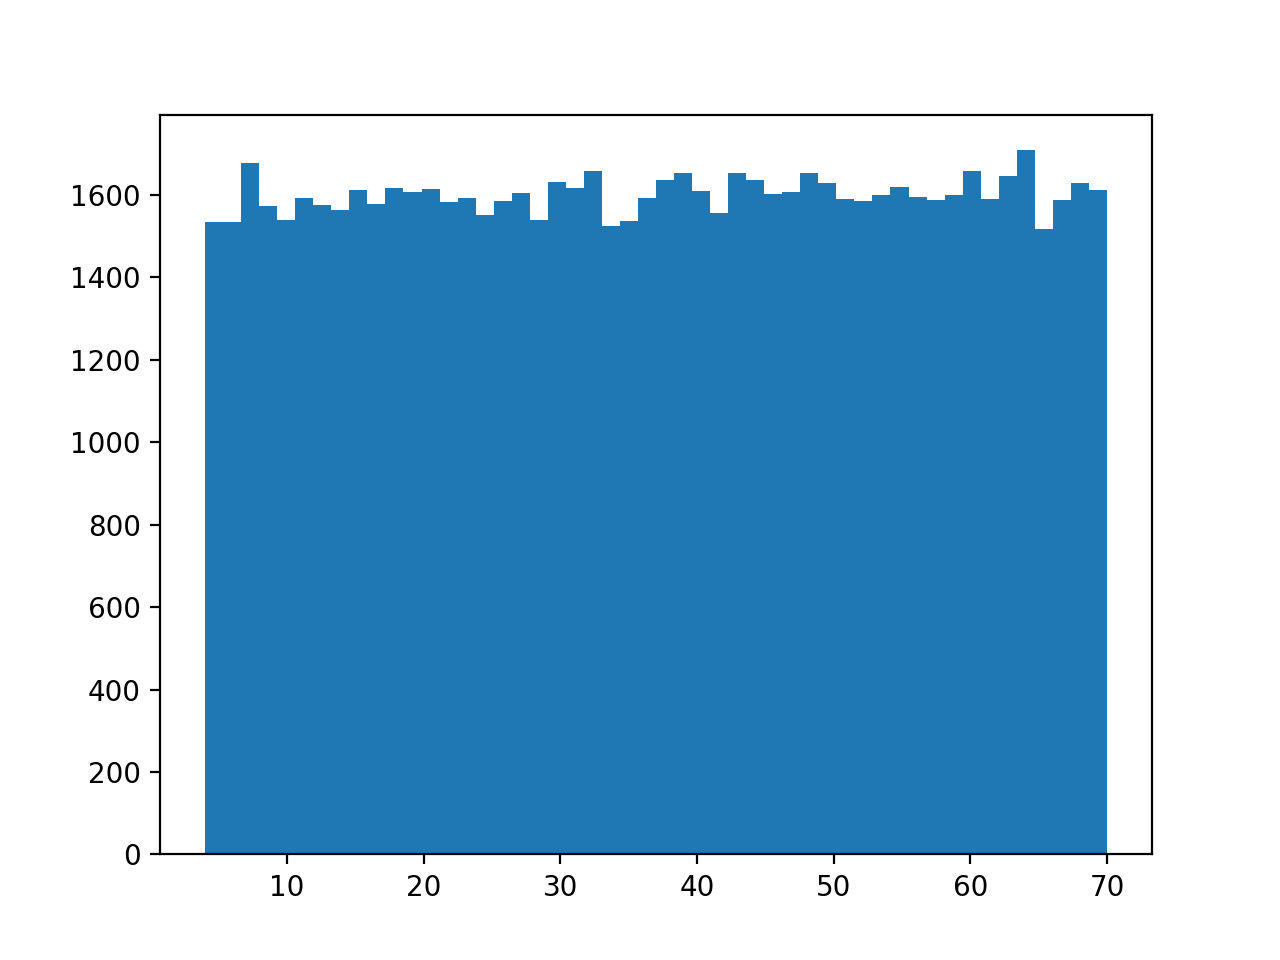

[39.752743 32.059307  4.004052 ... 65.01751  38.851006 39.310757]


In [24]:
%matplotlib notebook
plt.figure(320)
print(np.array(sn_info_per_event[:, 0]))
plt.hist(sn_info_per_event[:, 0], bins=50)
plt.show()

[ 238.10475  -131.4693   -615.7805   ...  492.56622   326.63324
   54.357296]
Avg: 45.189225 Max: 187 Min: 0


<IPython.core.display.Javascript object>


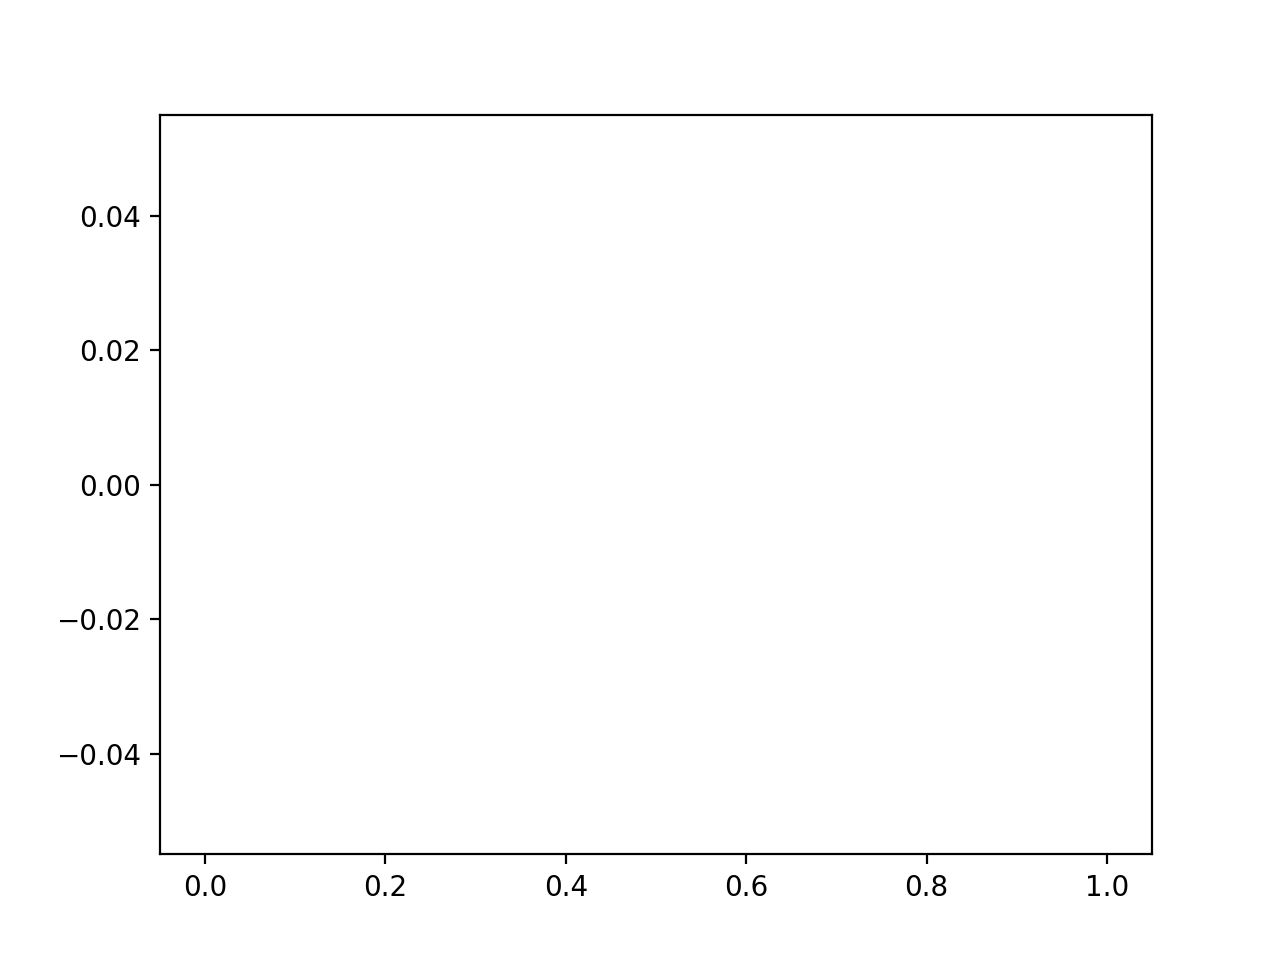

In [25]:
print(sn_info_per_event[:, 2])

#outside = np.where((np.abs(sn_info_per_event[:, 2]) > 675) & (np.abs(sn_info_per_event[:, 1] > 325)))[0]
outside = np.where(np.abs(sn_info_per_event[:, 2]) > 675)[0]

#outside = np.where((np.abs(sn_info_per_event[:, 2]) > 600) & (np.abs(sn_info_per_event[:, 2]) < 675) & (sn_info_per_event[:, 1] > 50) & (sn_info_per_event[:, 1] < 250))[0]

hlens = []
for i, hl in enumerate(sn_hit_list_per_event):
    if i in outside:
        continue
    hlens.append(len(hl))
print("Avg:", np.mean(hlens), "Max:", np.max(hlens), "Min:", np.min(hlens))

plt.figure(1234)
plt.hist(sn_info_per_event[outside, 2], bins=50)
plt.show()

## PE's per MeV (Per Event) RESTRICTED

<IPython.core.display.Javascript object>


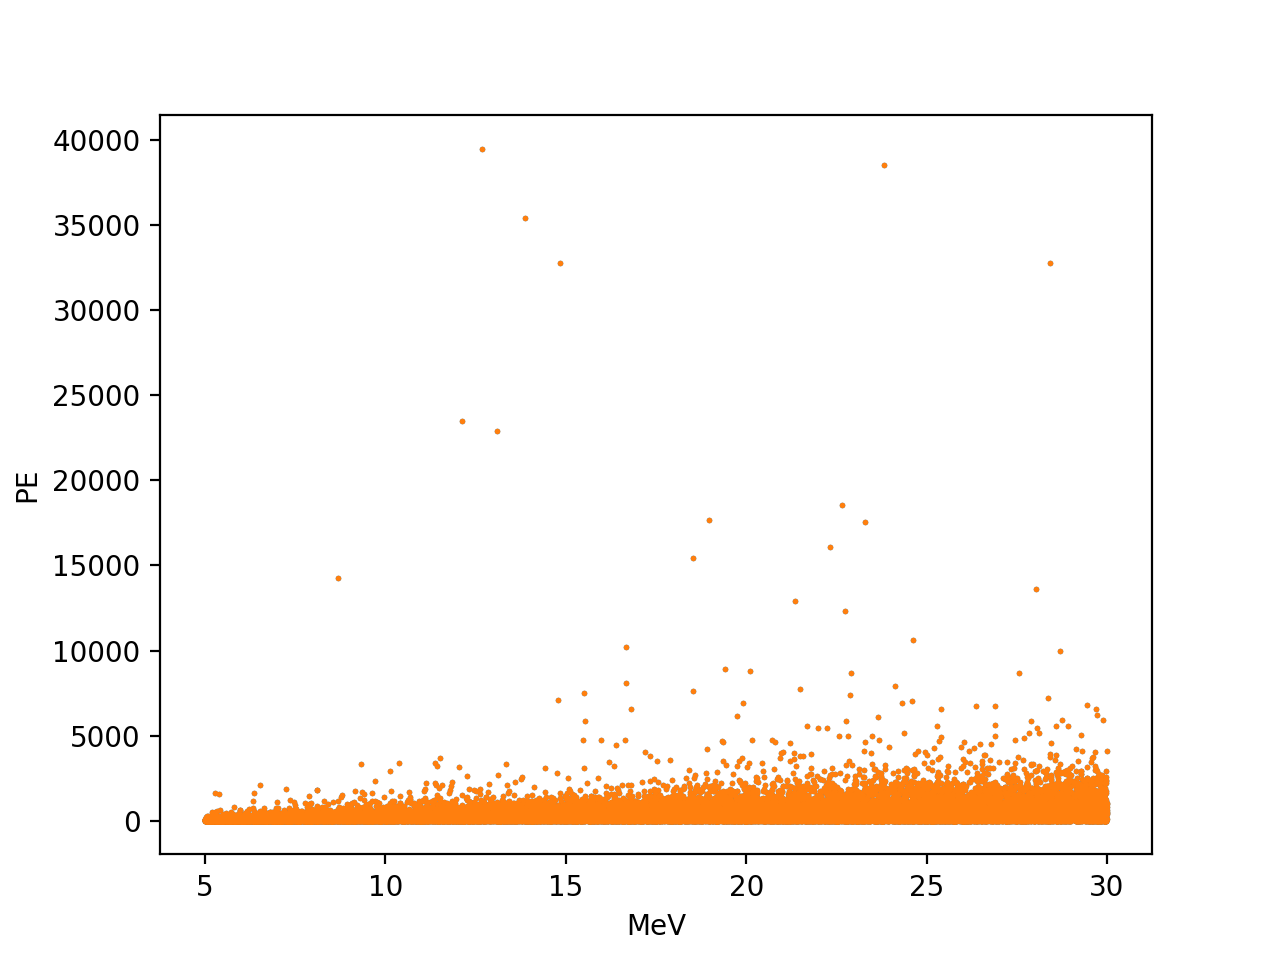

80000 (80000, 4)


ZeroDivisionError: division by zero

In [26]:
# PE's per MeV (PER EVENT)
%matplotlib notebook

min_e = 5
max_e = 30

# Fraction of hitless/low hit events
hit_lim = 1
low_hit = 0
total_hit = 0

plt.figure(12)
pes = []
pe_per_mev = []
energies = []
print(len(sn_hit_list_per_event), sn_info_per_event.shape)
for i, elist in enumerate(sn_hit_list_per_event):
    
    # Only wall arapucas
    if elist.shape != (0,):
        elist = elist[elist[:,5] > 0]
    
    # Only within geometry limits (see above cell)
    if i not in outside:
        #print("not outside")
         continue
    
    # Only within energy limits
    energy = (sn_info_per_event[i, 0])
    if energy < min_e:
        continue
    if energy > max_e:
        continue
    
    # Low hit event?
    total_hit += 1
    if len(elist) < hit_lim:
        low_hit += 1
    
    if elist.shape == (0,):
        pe = 0
    else:
        pe = np.sum(elist[:, -1])
    
    energies.append(energy)
    pes.append(pe)
    pe_per_mev.append(pe/energy)

# Fraction of low hit events
print("Fraction of low hit events", low_hit/total_hit)
#print(low_hit, total_hit)

pes = np.array(pes)
plt.scatter(energies, pes, s=2)

#plt.ylim(top=20, bottom=-1)

plt.xlabel("MeV")
plt.ylabel("PE")

print(np.mean(pe_per_mev))

coef = np.polyfit(energies, pes, 1)
poly1d_fn = np.poly1d(coef) 
#plt.plot(energies, poly1d_fn(energies), c='black', linewidth=2)
print(coef)

plt.figure()
h, bins, _ = plt.hist(energies, bins=np.arange(min_e, max_e + 1, 1))
h2, bins2, _ = plt.hist(energies, bins=np.arange(min_e, max_e + 1, 1), weights=pes)

me = []
ct = []
for i in range(len(h)):
    me.append((bins[i] + bins[i+1])/2)
    ct.append(h2[i]/h[i])

plt.figure()
plt.bar(bins[:-1], np.array(ct)/np.array(me))
plt.xlabel("MeV")
plt.ylabel("PE/MeV")
#plt.ylim(0, 26)


## PE's per MeV (Per Event) ALL EVENTS

80000 (80000, 4)
Fraction of low hit events 0.07803093297854648


<IPython.core.display.Javascript object>


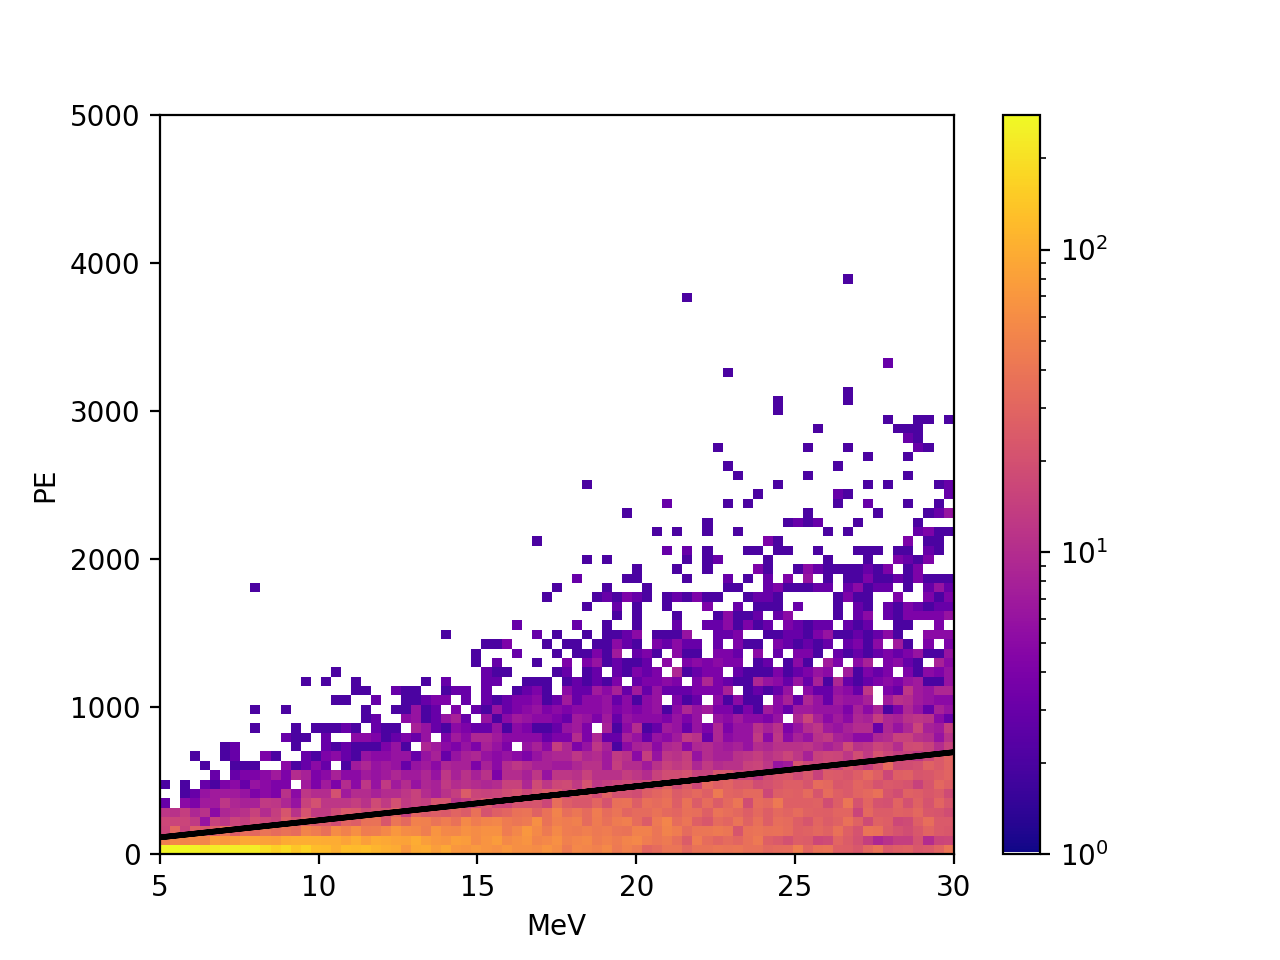

20.70173838535817
coef [23.0406279]


<IPython.core.display.Javascript object>


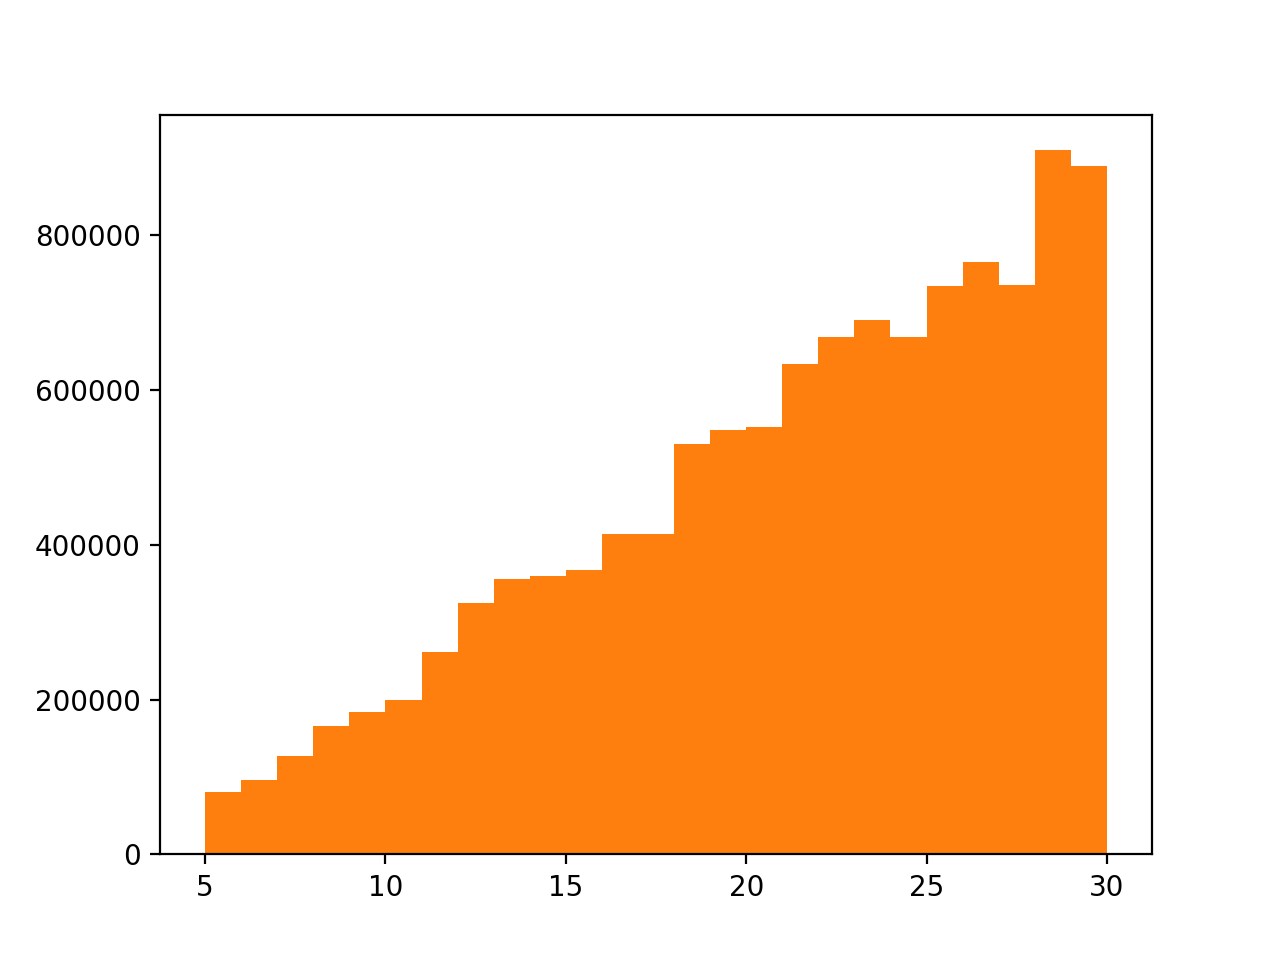

<IPython.core.display.Javascript object>


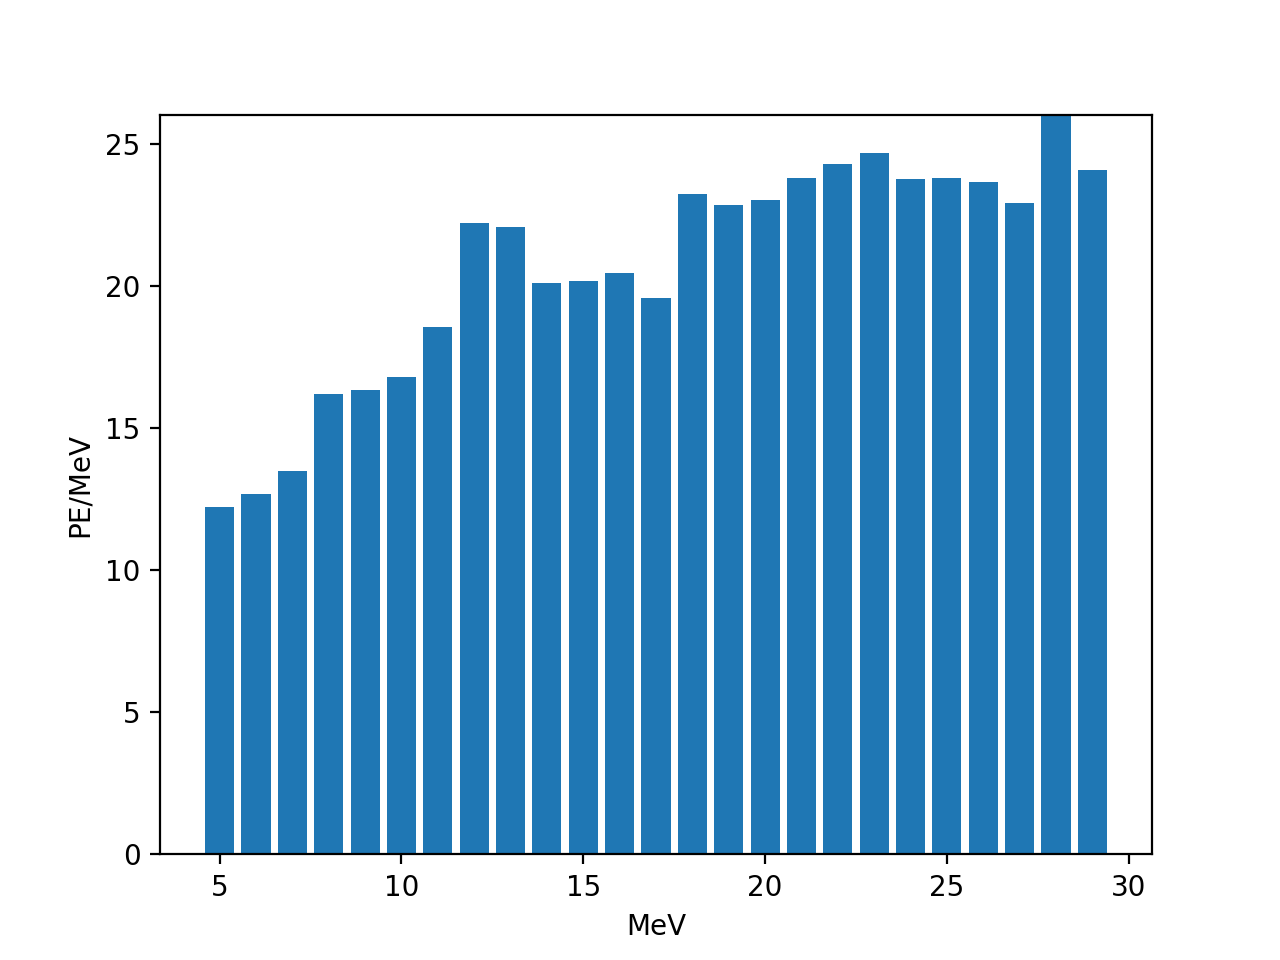

(0.0, 26.0)

In [28]:
# PE's per MeV (PER EVENT)
%matplotlib notebook

# For the histogram = 0 to be white
from matplotlib.colors import ListedColormap
import matplotlib as mpl
original_cmap = plt.cm.plasma
colors = original_cmap(np.arange(original_cmap.N))
colors[0, :] = np.array([1, 1, 1, 1])
custom_cmap = ListedColormap(colors)

min_e = 5
max_e = 30

# Fraction of hitless/low hit events
hit_lim = 1
low_hit = 0
total_hit = 0

plt.figure(12)
pes = []
pe_per_mev = []
energies = []
print(len(sn_hit_list_per_event), sn_info_per_event.shape)
for i, elist in enumerate(sn_hit_list_per_event):
    
    # Only within energy limits
    energy = (sn_info_per_event[i, 0])
    if energy < min_e:
        continue
    if energy > max_e:
        continue
    
    # Low hit event?
    total_hit += 1
    if len(elist) < hit_lim:
        low_hit += 1
    
    if elist.shape == (0,):
        pe = 0
    else:
        pe = np.sum(elist[:, -1])
    
    energies.append(energy)
    pes.append(pe)
    pe_per_mev.append(pe/energy)

# Fraction of low hit events
print("Fraction of low hit events", low_hit/total_hit)
#print(low_hit, total_hit)

pes = np.array(pes)
plt.scatter(energies, pes, s=1)
plt.xlabel("MeV")
plt.ylabel("PE")
#plt.ylim(top=5000)

bins_x = np.linspace(min_e, max_e, 80)
bins_y = np.linspace(0, 5000, 80)
plt.figure()
plt.hist2d(energies, pes, bins=[bins_x, bins_y], norm=mpl.colors.LogNorm(), cmap=custom_cmap)
plt.colorbar()
#plt.ylim(top=5000)

plt.xlabel("MeV")
plt.ylabel("PE")

print(np.mean(pe_per_mev))

X = np.array(energies).reshape(-1, 1)
coef, _, _, _ = np.linalg.lstsq(X, pes, rcond=None)

#coef = np.polyfit(energies, pes, 1)
#poly1d_fn = np.poly1d(coef) 
plt.plot(energies, energies*coef, c='black', linewidth=2)
print("coef", coef)

plt.figure()
h, bins, _ = plt.hist(energies, bins=np.arange(min_e, max_e + 1, 1))
h2, bins2, _ = plt.hist(energies, bins=np.arange(min_e, max_e + 1, 1), weights=pes)

me = []
ct = []
for i in range(len(h)):
    me.append((bins[i] + bins[i+1])/2)
    ct.append(h2[i]/h[i])

plt.figure()
plt.bar(bins[:-1], np.array(ct)/np.array(me))
plt.xlabel("MeV")
plt.ylabel("PE/MeV")
plt.ylim(0, 26)

## PE's Per MeV (PER HIT)

80000 (80000, 4)
PE/MeV per hit - mean: 0.5623469254630499
MAX/MIN: 22913.927734375 2.437692403793335


/cvmfs/sft.cern.ch/lcg/views/LCG_104a_swan/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3441: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


LINEAR FIT: [ 0.23706153 11.73880915]


<IPython.core.display.Javascript object>


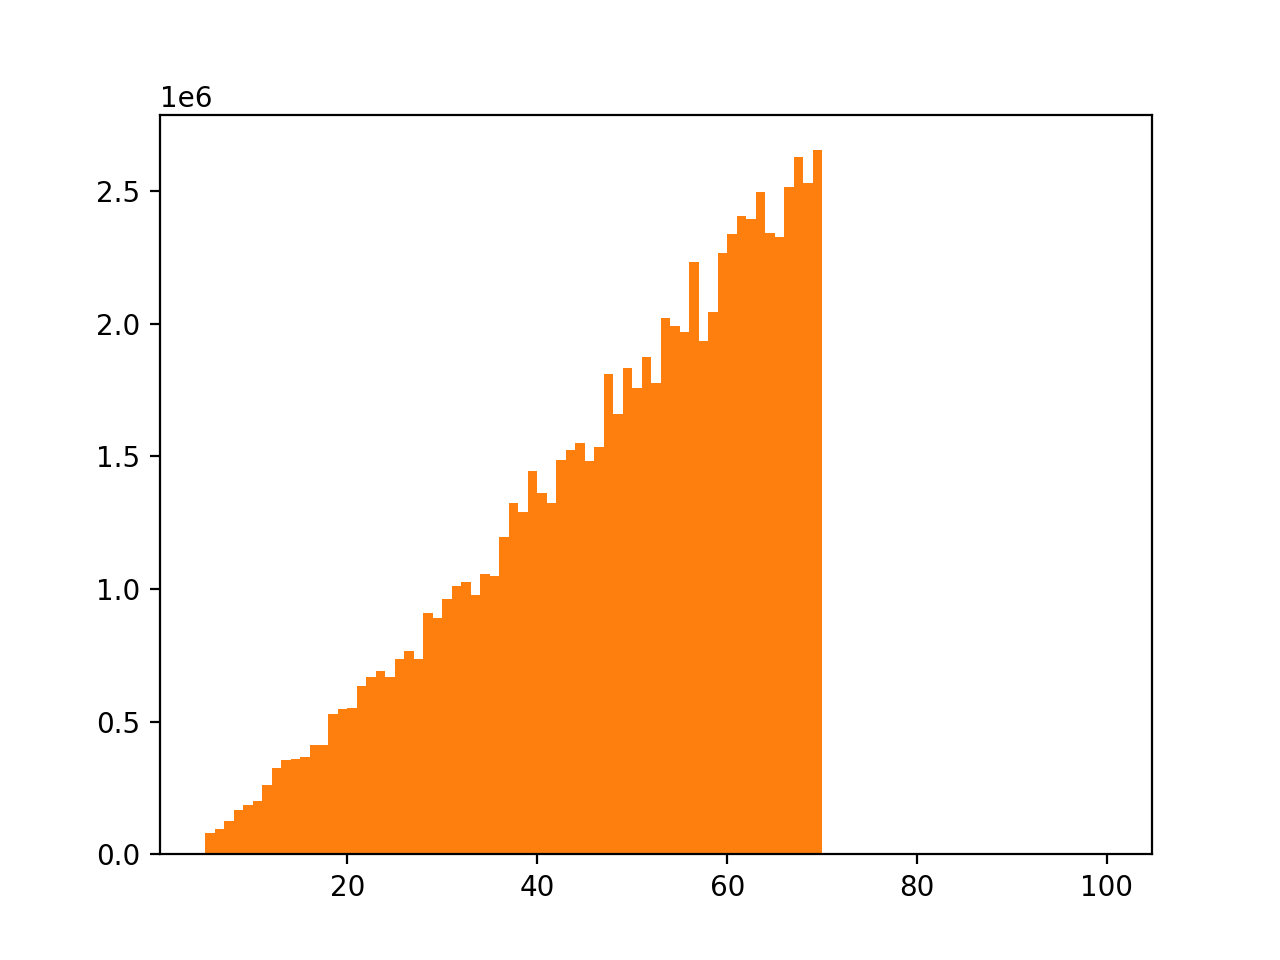

/tmp/ipykernel_19654/1241909531.py:50: RuntimeWarning: invalid value encountered in double_scalars
  ct.append(h2[i]/h[i])


<IPython.core.display.Javascript object>


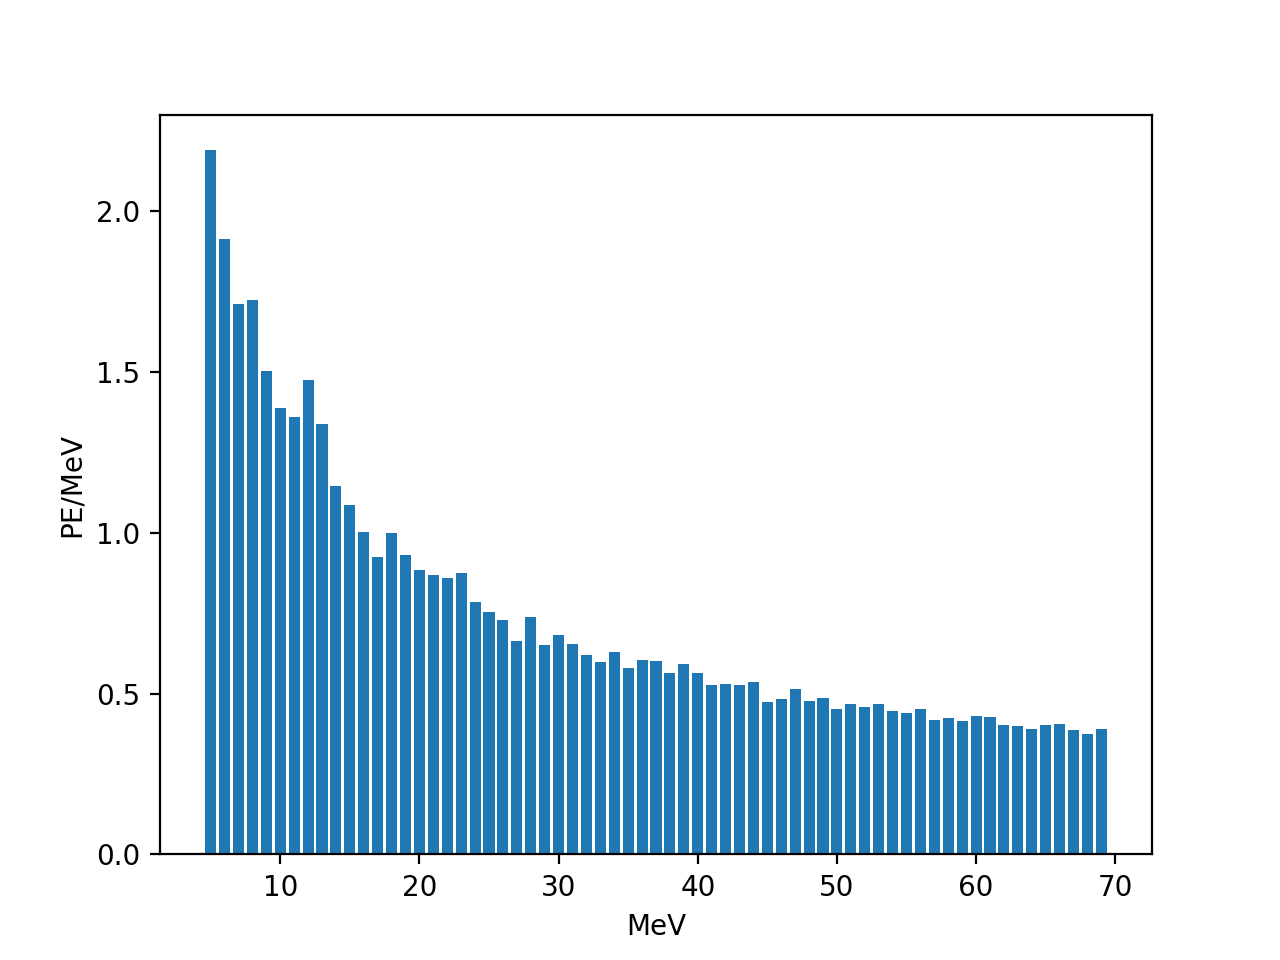

Text(0, 0.5, 'PE/MeV')

In [10]:
# Now we will look at the average PE PER HIT
%matplotlib notebook

min_e = 5
max_e = 100

plt.figure(12)
pes = []
pes_per_mev = []
energies = []

print(len(sn_hit_list_per_event), sn_info_per_event.shape)
for i, elist in enumerate(sn_hit_list_per_event):
    energy = (sn_info_per_event[i, 0])
    if energy < min_e:
        continue
    if energy > max_e:
        continue
    
    if elist.shape == (0,):
        continue
        
    energies.extend([energy] * len(elist[:, -1]))
    
    pes.extend(elist[:, -1])
    pes_per_mev.extend(elist[:, -1]/np.array(energy))

pes = np.array(pes)
plt.scatter(energies, pes, s=2)
plt.ylim(top=1000, bottom=2)
plt.ylabel("PE")
plt.xlabel("MeV")

print("PE/MeV per hit - mean:", np.mean(pes_per_mev))
print("MAX/MIN:", np.max(pes), np.min(pes))

coef = np.polyfit(energies, pes, 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(energies, poly1d_fn(energies), c='black', linewidth=2)
print("LINEAR FIT:", coef)

plt.figure()
h, bins, _ = plt.hist(energies, bins=np.arange(min_e, max_e + 1, 1))
h2, bins2, _ = plt.hist(energies, bins=np.arange(min_e, max_e + 1, 1), weights=pes)

me = []
ct = []
for i in range(len(h)):
    me.append((bins[i] + bins[i+1])/2)
    ct.append(h2[i]/h[i])

plt.figure()
plt.bar(bins[:-1], np.array(ct)/np.array(me))
plt.xlabel("MeV")
plt.ylabel("PE/MeV")
#plt.ylim(0, 26)

In [ ]:
aux.distance_to_event_number(125, model="GARCHING")

<IPython.core.display.Javascript object>


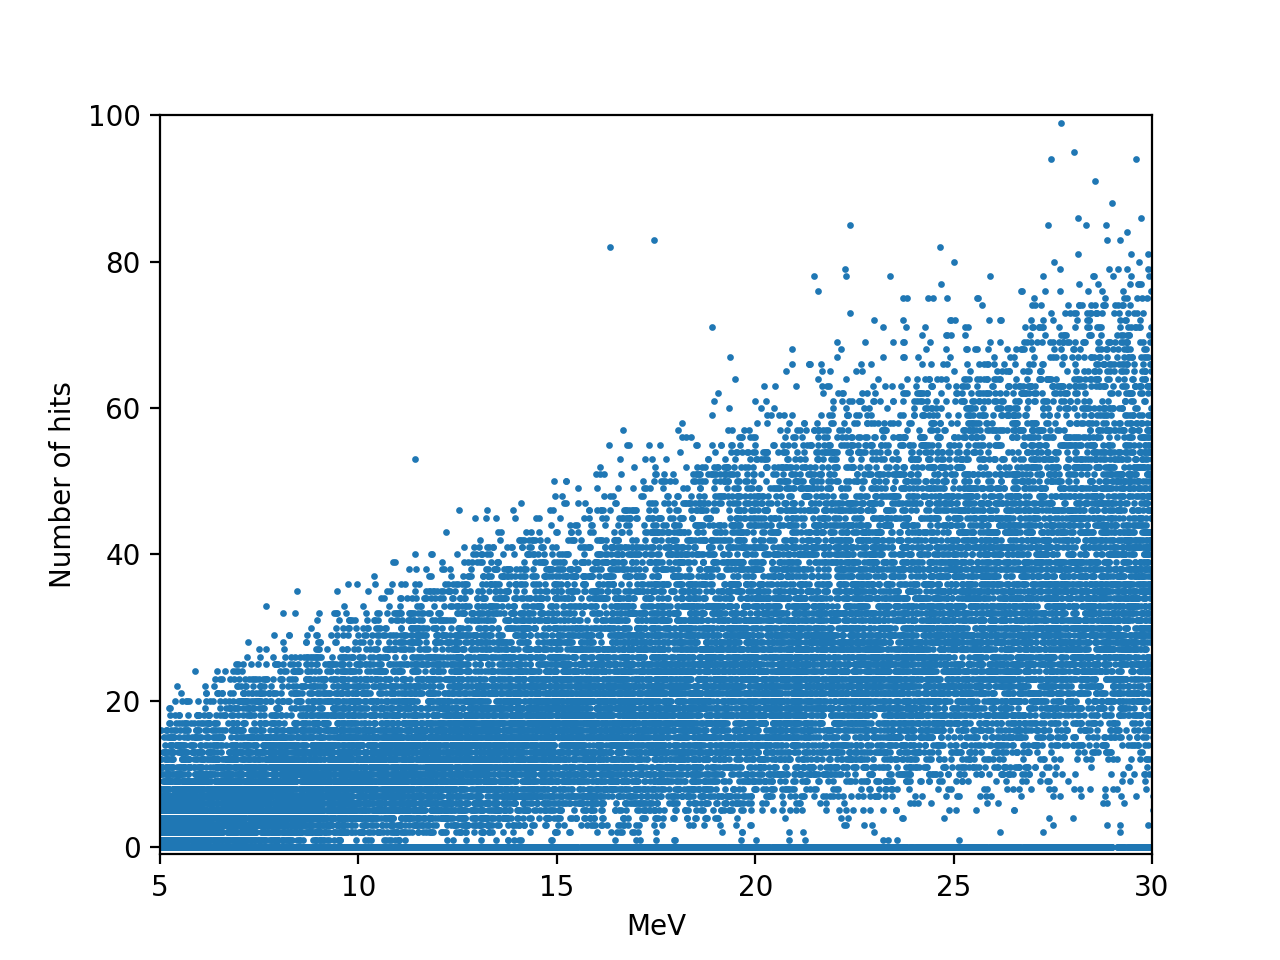

<IPython.core.display.Javascript object>


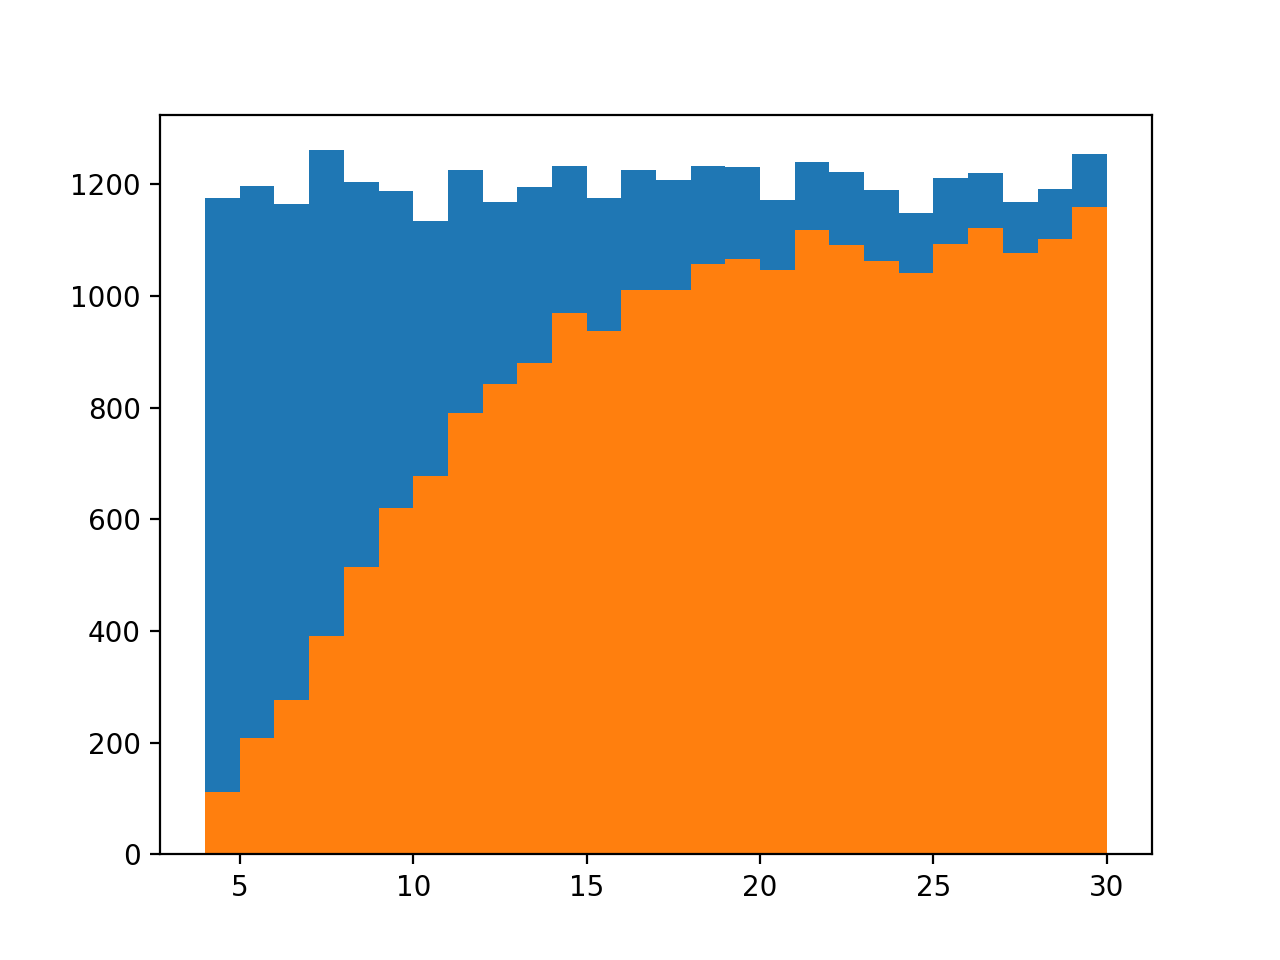

<IPython.core.display.Javascript object>


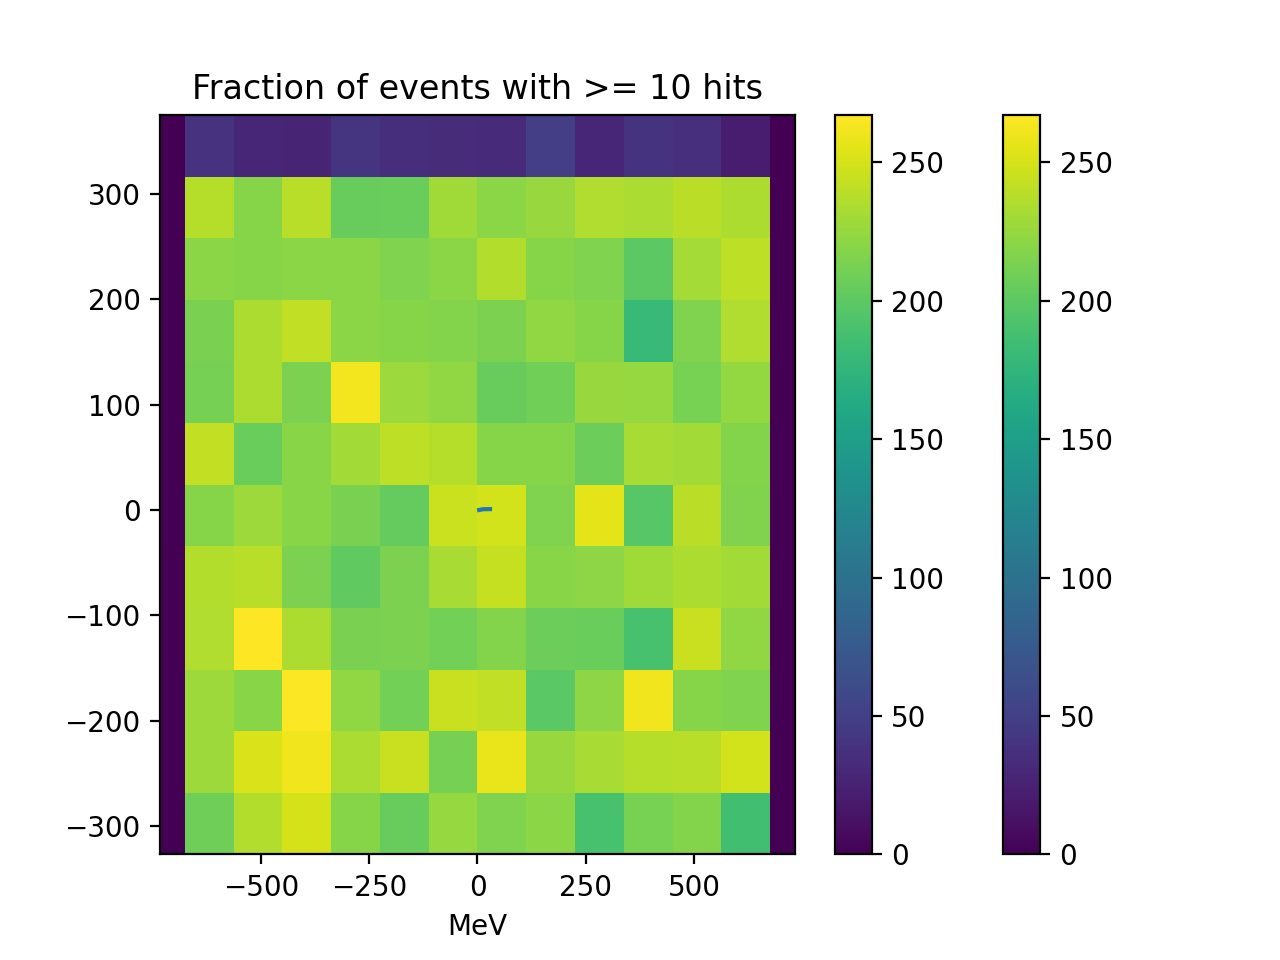

Text(0.5, 1.0, 'Fraction of events with >= 10 hits')

In [13]:
%matplotlib notebook

hit_lim = 10

plt.figure(120)
hit_nums = []
high_nums = []

hit_num_per_mev = []
energies = []
h_energies = []
for i, elist in enumerate(sn_hit_list_per_event):
    energy = sn_info_per_event[i, 0]
    hit_num = len(elist)
    
    if hit_num >= hit_lim:
        high_nums.append(hit_num)
        h_energies.append(energy)
    
    energies.append(energy)

    hit_nums.append(hit_num)
    hit_num_per_mev.append(hit_num/energy)

plt.scatter(energies, hit_nums, s=2)
plt.xlabel('MeV')
plt.ylabel('Number of hits')

#plt.ylim(0, 10)
plt.xlim(5, 30)
plt.ylim(-1, 100)

plt.figure(20)
n, b, _ = plt.hist(energies, bins=np.arange(4, 31, 1))
nh, _, _ = plt.hist(h_energies, bins=np.arange(4, 31, 1))

plt.figure(30)
plt.plot(b[:-1], nh/n)
plt.xlabel('MeV')
plt.title('Fraction of events with >= {} hits'.format(hit_lim))

# Percentage of hitless 

<IPython.core.display.Javascript object>


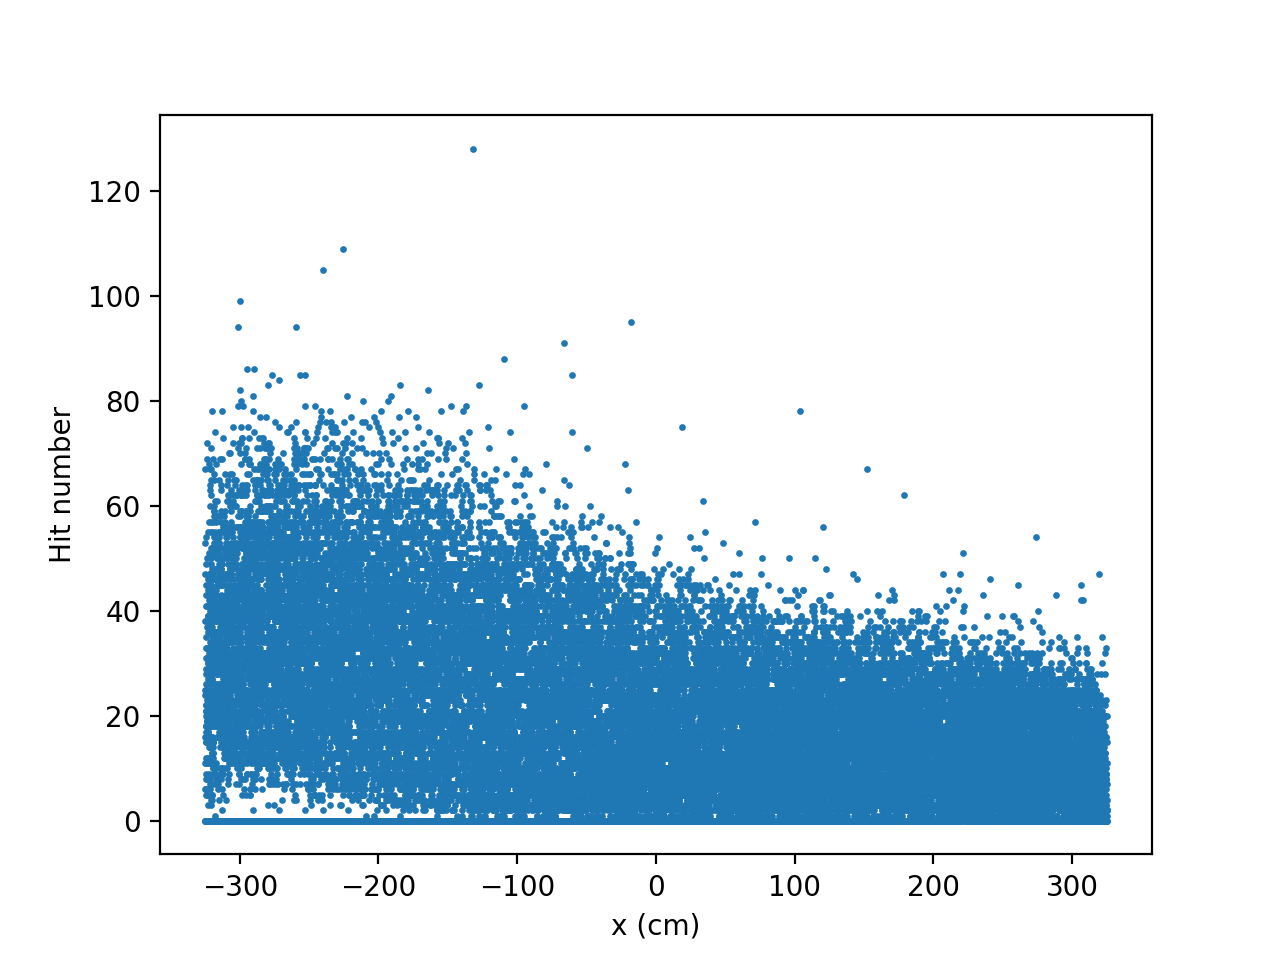

<IPython.core.display.Javascript object>


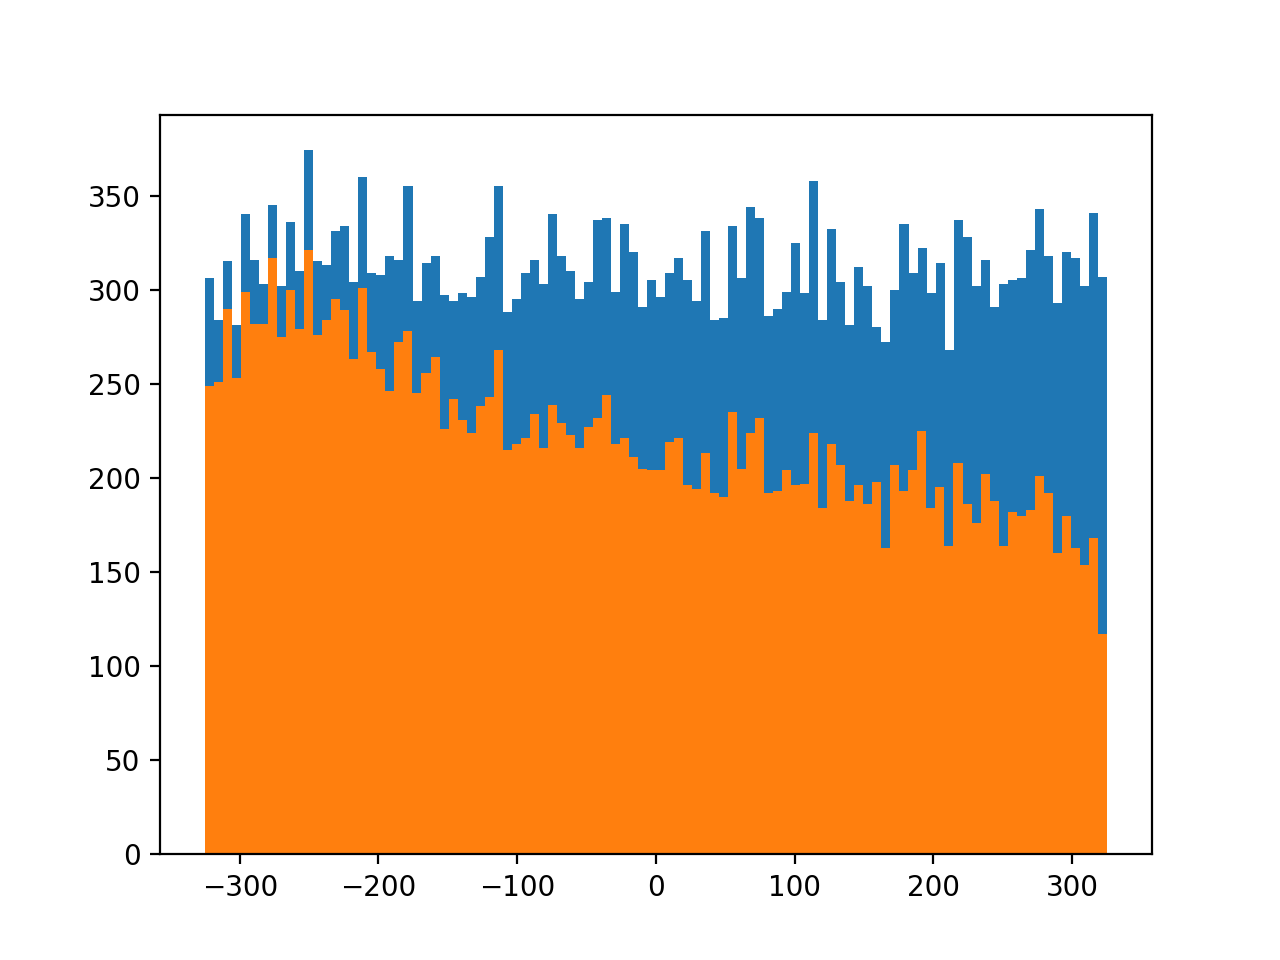

<IPython.core.display.Javascript object>


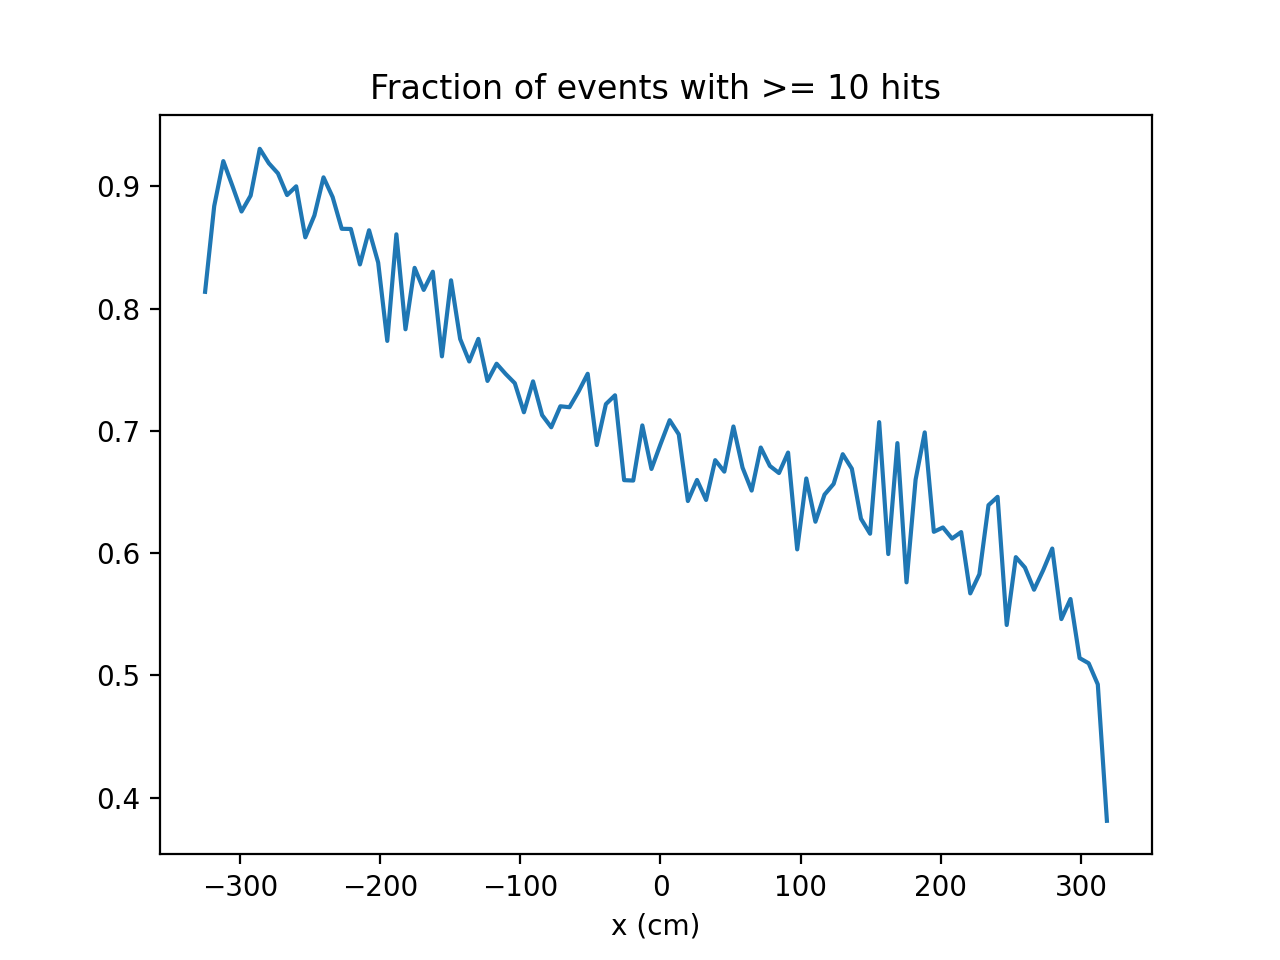

Text(0.5, 1.0, 'Fraction of events with >= 10 hits')

In [15]:
# Number of events vs true X (as requested by Laura)
#true_x = sn_info_per_event[:, 1]

hit_lim = 10

plt.figure(190)
hit_nums = []
high_nums = []

hit_num_per_cm = []
xs = []
h_xs = []
for i, elist in enumerate(sn_hit_list_per_event):
    x = sn_info_per_event[i, 1]
    energy = sn_info_per_event[i, 0]
    
    # We are only interested in a certain energy range
    if energy > 30:
        continue
    
    hit_num = len(elist)
    
    if hit_num >= hit_lim:
        high_nums.append(hit_num)
        h_xs.append(x)
    
    xs.append(x)

    hit_nums.append(hit_num)
    hit_num_per_cm.append(hit_num/x)

plt.scatter(xs, hit_nums, s=2)
plt.xlabel("x (cm)")
plt.ylabel('Hit number')

#plt.ylim(0, 10)

plt.figure(200)
n, b, _ = plt.hist(xs, bins=100)
nh, _, _ = plt.hist(h_xs, bins=100)

plt.figure(300)
plt.plot(b[:-1], nh/n)
plt.xlabel('x (cm)')
plt.title('Fraction of events with >= {} hits'.format(hit_lim))



## 2D light maps

80000 (80000, 4)
AVERAGE LY: 20.70173838535817


<IPython.core.display.Javascript object>


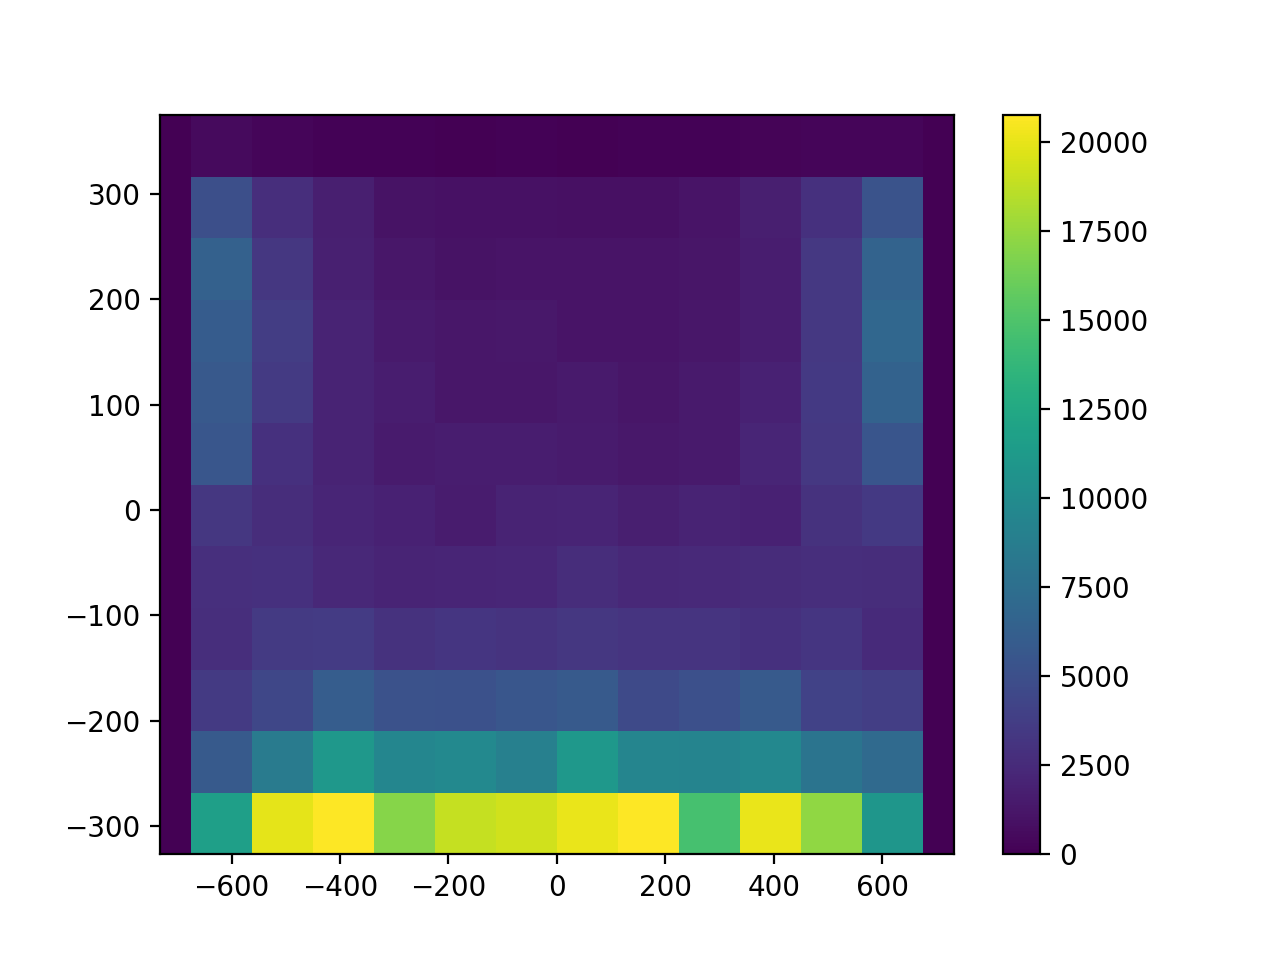

/tmp/ipykernel_19654/1430252585.py:80: RuntimeWarning: invalid value encountered in divide
  light_map = hist_w/hist


<IPython.core.display.Javascript object>


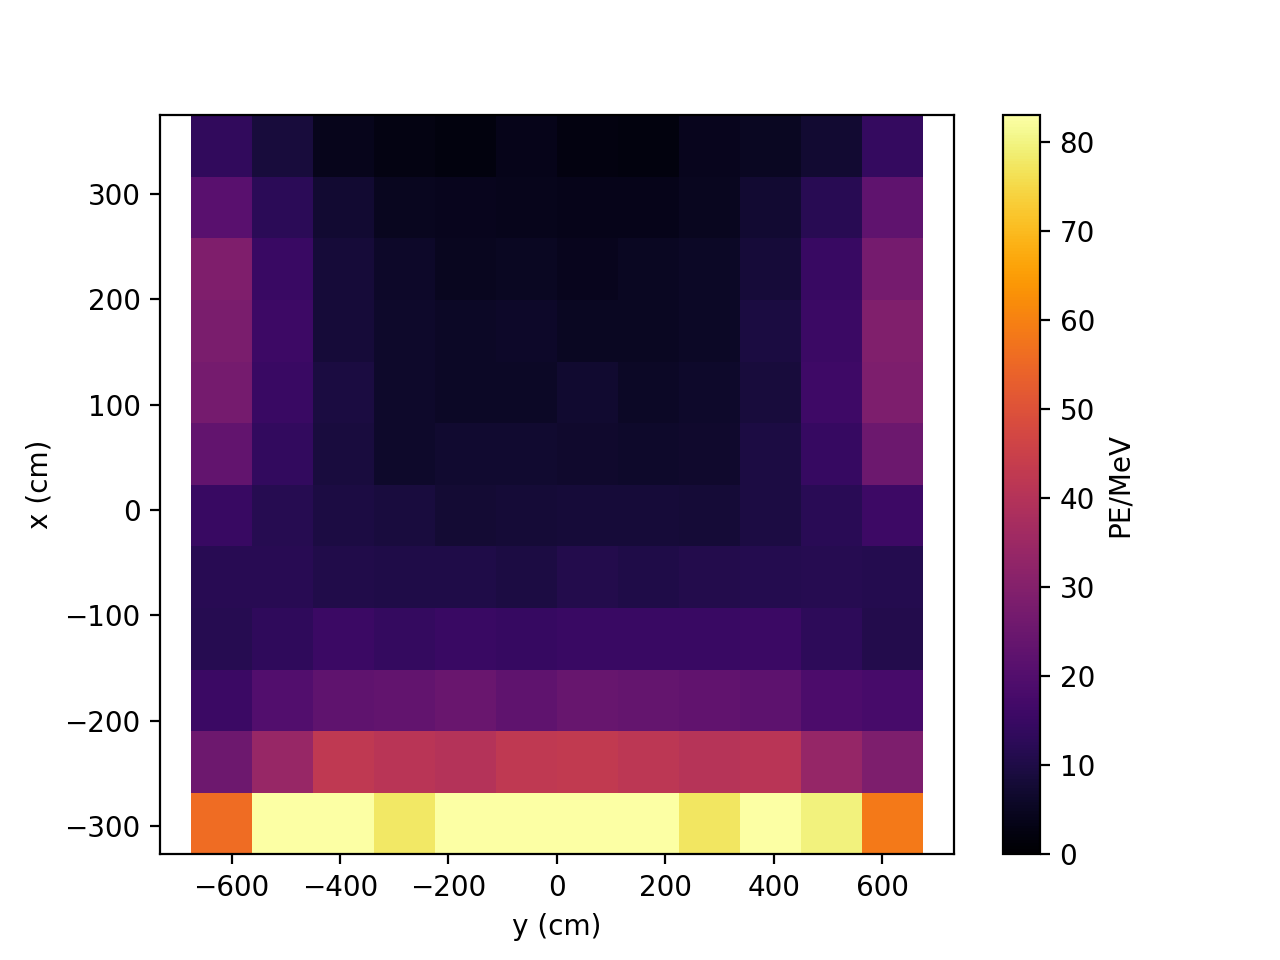

Text(0, 0.5, 'x (cm)')

In [18]:
# PE's per MeV (PER EVENT)
%matplotlib notebook

min_e = 5
max_e = 30

# Fraction of hitless/low hit events
hit_lim = 1
low_hit = 0
total_hit = 0

pes = []
pe_per_mev = []
energies = []

xs = []
ys = []
zs = []

# Cut in z?
min_z = 0
max_z = 2100

print(len(sn_hit_list_per_event), sn_info_per_event.shape)

for i, elist in enumerate(sn_hit_list_per_event):
    x = sn_info_per_event[i, 1]
    y = sn_info_per_event[i, 2]
    z = sn_info_per_event[i, 3]
    
    # Only within energy limits
    energy = sn_info_per_event[i, 0]
    if energy < min_e:
        continue
    if energy > max_e:
        continue
        
    # Only within z limits
    if z < min_z:
        continue
    if z > max_z:
        continue
        
    # Low hit event?
    total_hit += 1
    if len(elist) < hit_lim:
        low_hit += 1
    
    if elist.shape == (0,):
        pe = 0
    else:
        pe = np.sum(elist[:, -1])
    
    energies.append(energy)
    pes.append(pe)
    pe_per_mev.append(pe/energy)
    
    xs.append(x)
    ys.append(y)
    zs.append(z)

# Average LY for the sample collected
print("AVERAGE LY:", np.mean(pe_per_mev))
    
    
# Get the number of values in each bin
bins_x = np.concatenate((np.array([-732]), np.linspace(-675, 675, num=13),np.array([732])))
bins_y = np.linspace(-327, 375, num=13)

plt.figure(30)
hist, _, _, _ = plt.hist2d(ys, xs, bins=(bins_x, bins_y))
plt.colorbar()

# Get the histogram weighted by pes_per_mev
plt.figure(40)
hist_w, xedges, yedges, _ = plt.hist2d(ys, xs, bins=(bins_x, bins_y), weights=pe_per_mev)
plt.colorbar()

# Divide by the number of values in each bin to get the average
light_map = hist_w/hist
fig, ax = plt.subplots()
cax = ax.pcolormesh(xedges, yedges, light_map.T, cmap='inferno', vmin=0, vmax=83)
fig.colorbar(cax, label='PE/MeV')

ax.set_xlabel("y (cm)")
ax.set_ylabel("x (cm)")



## Time distribution for arriving photons (?)

<IPython.core.display.Javascript object>


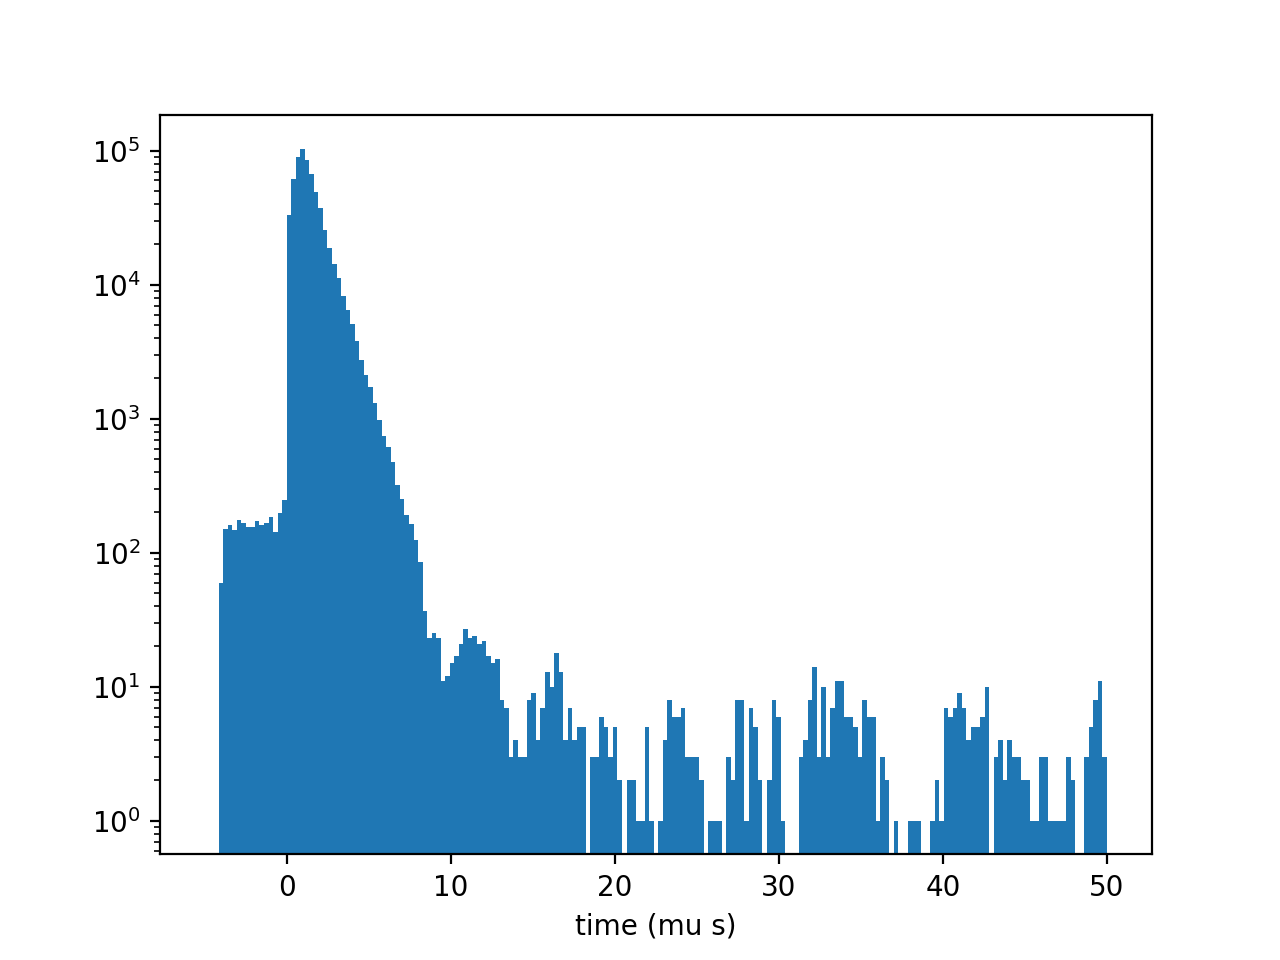

Text(0.5, 0, 'time (mu s)')

In [20]:
%matplotlib notebook

min_e = 5
max_e = 30

energies = []
pes = []
pe_per_mev = []
all_peak_times = []

for i, elist in enumerate(sn_hit_list_per_event):
    
    # Only within energy limits
    energy = (sn_info_per_event[i, 0])
    if energy < min_e:
        continue
    if energy > max_e:
        continue
    
    if elist.shape == (0,):
        continue
    
    peak_times = elist[:, 3]
    all_peak_times.extend(peak_times)
    
    if elist.shape == (0,):
        pe = 0
    else:
        pe = np.sum(elist[:, -1])
    
    energies.append(energy)
    pes.append(pe)
    pe_per_mev.append(pe/energy)

plt.figure()
#bins = np.linspace(-5, 3000, 200)
bins = np.linspace(-5, 50, 200)
plt.hist(all_peak_times, bins=bins)
#plt.ylim(top=2e5, bottom=4e-1)
plt.yscale('log')
plt.xlabel("time (mu s)")


## Checks for the GNN. See if the SN hits make sense

In [ ]:
# sn_hit_list_per_event, sn_info_per_event

pes 

for i, hl in enumerate(sn_hit_list_per_event):
    